# Prática 01 — Caminho Mínimo

**Disciplina:** Teoria de Grafos  
**Objetivo:** Implementar e comparar algoritmo de Dijkstra e heurística gulosa para caminho mínimo.

---

In [23]:
# Imports necessários
from typing import Dict, List, Tuple, Optional
from collections import deque
from math import inf
import heapq, random, os
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

---
# PARTE 1: ALGORITMO DE DIJKSTRA
---

## I. Implementação do Algoritmo de Dijkstra

Algoritmo para obtenção do caminho mínimo de **origem única** e **múltiplos destinos**.

In [24]:
def dijkstra(adj: Dict[int, List[Tuple[int, float]]], origem: int = 0):
    """
    Algoritmo de Dijkstra para caminho mínimo de origem única.
    
    Parâmetros:
    - adj: grafo em lista de adjacência {u: [(v, peso), ...]}
    - origem: vértice de origem
    
    Retorna:
    - dist: dicionário com distâncias mínimas
    - parent: dicionário com árvore de caminhos
    - comparacoes: número de comparações realizadas
    """
    # Validações
    if not adj or origem not in adj:
        raise ValueError('Grafo vazio ou origem inválida')
    
    # Verificar pesos não negativos
    for u, vizinhos in adj.items():
        for v, peso in vizinhos:
            if peso < 0:
                raise ValueError(f'Dijkstra requer pesos não negativos (aresta {u}->{v} tem peso {peso})')
    
    # Inicialização
    dist = {u: inf for u in adj}
    parent = {u: None for u in adj}
    dist[origem] = 0.0
    
    # Fila de prioridade (heap)
    pq = [(0.0, origem)]
    comparacoes = 0
    
    # Loop principal
    while pq:
        dist_u, u = heapq.heappop(pq)
        
        # Ignorar duplicatas
        if dist_u != dist[u]:
            continue
        
        # Relaxamento das arestas
        for v, peso in adj[u]:
            comparacoes += 1  # Contar comparação
            nova_dist = dist[u] + peso
            
            if nova_dist < dist[v]:
                dist[v] = nova_dist
                parent[v] = u
                heapq.heappush(pq, (nova_dist, v))
    
    return dist, parent, comparacoes

## II. Teste do Algoritmo

### Parâmetros

In [25]:
# Configurações
N_MIN = 4
N_MAX = 100000  # Limite: até 1.000.000
SEED = 42    # Para reprodutibilidade
ORIGEM = 0   # Vértice de origem

### (a) Gerar grafos completos com pesos > 0

In [ ]:
def gerar_grafo_completo(n: int, peso_min: float = 1.0, peso_max: float = 10.0, seed: int = None):
    """
    Gera grafo completo dirigido com n vértices e pesos estritamente positivos.
    
    Retorna: dicionário {u: [(v, peso), ...]}
    """
    if seed is not None:
        random.seed(seed)
    
    adj = {u: [] for u in range(n)}
    
    for u in range(n):
        for v in range(n):
            if u != v:  # Sem laços
                peso = random.uniform(peso_min, peso_max)
                adj[u].append((v, peso))
    
    return adj

# Teste
grafo_teste = gerar_grafo_completo(5, seed=SEED)
print(f"Grafo com 5 vértices: {len(grafo_teste)} vértices, {sum(len(v) for v in grafo_teste.values())} arestas")

Grafo com 5 vértices: 5 vértices, 20 arestas


### (b) Armazenar grafos em estrutura de dados

**Estrutura escolhida:** Lista de adjacência com dicionário  
**Formato:** `{vértice: [(vizinho, peso), ...]}`

In [27]:
# Gerar grafos de N_MIN até N_MAX
ns = list(range(N_MIN, N_MAX + 1))
grafos = [gerar_grafo_completo(n, seed=SEED) for n in ns]

print(f"Gerados {len(grafos)} grafos (n = {N_MIN} até {N_MAX})")
print(f"Exemplo: grafo com n={ns[0]} tem {sum(len(v) for v in grafos[0].values())} arestas")

KeyboardInterrupt: 

### (c) Aplicar algoritmo de Dijkstra (origem = vértice 0)

In [ ]:
# Aplicar Dijkstra em cada grafo
resultados = [dijkstra(g, origem=ORIGEM) for g in grafos]

print(f"Dijkstra aplicado em {len(resultados)} grafos")
print(f"\nExemplos (n={ns[0]}, {ns[1]}, {ns[2]}):")
for i in range(3):
    dist, parent, comp = resultados[i]
    print(f"  n={ns[i]}: {comp} comparações")

Dijkstra aplicado em 97 grafos

Exemplos (n=4, 5, 6):
  n=4: 12 comparações
  n=5: 20 comparações
  n=6: 30 comparações


### (d) Contar número de comparações

In [ ]:
# Extrair contagem de comparações
comparacoes = [r[2] for r in resultados]

# Exibir tabela
print('n\tComparações')
print('-' * 25)
for n, comp in zip(ns, comparacoes):
    print(f'{n}\t{comp:,}')

# Salvar em arquivo
os.makedirs('resultados/dijkstra', exist_ok=True)
with open('resultados/dijkstra/comparacoes.txt', 'w') as f:
    f.write('n\tcomparacoes\n')
    for n, comp in zip(ns, comparacoes):
        f.write(f'{n}\t{comp}\n')
print('\n[OK] Tabela salva em: resultados/dijkstra/comparacoes.txt')

n	Comparações
-------------------------
4	12
5	20
6	30
7	42
8	56
9	72
10	90
11	110
12	132
13	156
14	182
15	210
16	240
17	272
18	306
19	342
20	380
21	420
22	462
23	506
24	552
25	600
26	650
27	702
28	756
29	812
30	870
31	930
32	992
33	1,056
34	1,122
35	1,190
36	1,260
37	1,332
38	1,406
39	1,482
40	1,560
41	1,640
42	1,722
43	1,806
44	1,892
45	1,980
46	2,070
47	2,162
48	2,256
49	2,352
50	2,450
51	2,550
52	2,652
53	2,756
54	2,862
55	2,970
56	3,080
57	3,192
58	3,306
59	3,422
60	3,540
61	3,660
62	3,782
63	3,906
64	4,032
65	4,160
66	4,290
67	4,422
68	4,556
69	4,692
70	4,830
71	4,970
72	5,112
73	5,256
74	5,402
75	5,550
76	5,700
77	5,852
78	6,006
79	6,162
80	6,320
81	6,480
82	6,642
83	6,806
84	6,972
85	7,140
86	7,310
87	7,482
88	7,656
89	7,832
90	8,010
91	8,190
92	8,372
93	8,556
94	8,742
95	8,930
96	9,120
97	9,312
98	9,506
99	9,702
100	9,900

[OK] Tabela salva em: resultados/dijkstra/comparacoes.txt


### (e) Plotar gráfico: n (vértices) vs comparações

[OK] Gráfico salvo em: resultados/dijkstra/img/comparacoes.png


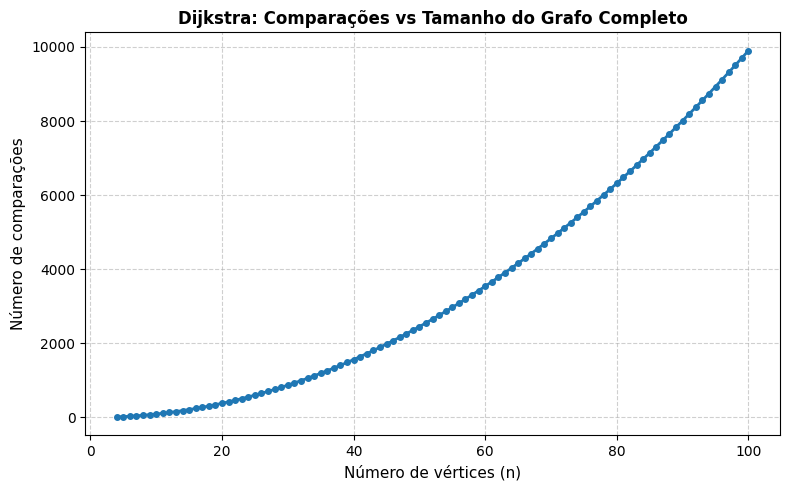

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(ns, comparacoes, marker='o', linewidth=2, markersize=4)
plt.xlabel('Número de vértices (n)', fontsize=11)
plt.ylabel('Número de comparações', fontsize=11)
plt.title('Dijkstra: Comparações vs Tamanho do Grafo Completo', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Salvar imagem
os.makedirs('resultados/dijkstra', exist_ok=True)
plt.savefig('resultados/dijkstra/comparacoes.png', dpi=150, bbox_inches='tight')
print('[OK] Gráfico salvo em: resultados/dijkstra/comparacoes.png')
plt.show()

### (f) Aplicar em instâncias grandes (10k e 1M vértices)

**Origem:** Vértice 0  
**Objetivo:** Mostrar número de comparações em cada instância

In [ ]:
def carregar_grafo_ewd(caminho: str):
    """
    Carrega grafo em formato EWD (Sedgewick):
      Linha 1: V (vértices)
      Linha 2: E (arestas)
      Linhas seguintes: u v peso
    """
    with open(caminho, 'r', encoding='utf-8') as f:
        V = int(f.readline().strip())
        E = int(f.readline().strip())
        adj = {i: [] for i in range(V)}
        
        for _ in range(E):
            linha = f.readline().strip()
            if not linha:
                break
            u, v, peso = linha.split()[:3]
            adj[int(u)].append((int(v), float(peso)))
    
    return adj


def executar_instancia_grande(caminho: str, nome: str, salvar_id: str):
    """Executa Dijkstra em instância grande, mostra e salva comparações."""
    if not os.path.exists(caminho):
        print(f'⚠️  Arquivo não encontrado: {nome}')
        print(f'   Caminho: {caminho}')
        return None
    
    print(f'\n{"="*60}')
    print(f'Processando: {nome}')
    print(f'{"="*60}')
    
    print('Carregando grafo...')
    adj = carregar_grafo_ewd(caminho)
    print(f'✓ Grafo carregado: {len(adj):,} vértices')
    
    print(f'Executando Dijkstra (origem = {ORIGEM})...')
    dist, parent, comp = dijkstra(adj, origem=ORIGEM)
    
    vertices_alcancados = sum(1 for d in dist.values() if d != inf)
    
    print(f'\n📊 RESULTADOS:')
    print(f'   Vértices: {len(dist):,}')
    print(f'   Comparações: {comp:,}')
    print(f'   Vértices alcançados: {vertices_alcancados:,}')
    
    # Salvar resultados
    os.makedirs('resultados/dijkstra/instancias', exist_ok=True)
    arquivo_resultado = f'resultados/dijkstra/instancias/{salvar_id}_dijkstra.txt'
    with open(arquivo_resultado, 'w', encoding='utf-8') as f:
        f.write(f'DIJKSTRA - {nome}\n')
        f.write(f'{"="*60}\n')
        f.write(f'Origem: {ORIGEM}\n')
        f.write(f'Vértices: {len(dist):,}\n')
        f.write(f'Comparações: {comp:,}\n')
        f.write(f'Vértices alcançados: {vertices_alcancados:,}\n')
    
    print(f'💾 Resultado salvo em: {arquivo_resultado}')
    
    return comp

In [ ]:
# Caminhos das instâncias (atualize conforme seu ambiente)
caminho_10k = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt'
caminho_1m = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\largeEWD - contains one million vertices and 15172126 edges.txt'

# Executar instância 10k
comp_dijkstra_10k = executar_instancia_grande(caminho_10k, 'Instância 10.000 vértices', '10k')

# Executar instância 1M (descomente se desejar rodar)
comp_dijkstra_1m = executar_instancia_grande(caminho_1m, 'Instância 1.000.000 vértices', '1m')

---
# PARTE 2: HEURÍSTICA GULOSA
---

## I. Implementação da Heurística Gulosa

Heurística gulosa simples baseada em **vizinho mais próximo**.

In [ ]:
def heuristica_gulosa(adj: Dict[int, List[Tuple[int, float]]], origem: int = 0):
    """
    Heurística gulosa para caminho mínimo (vizinho mais próximo).
    
    ATENÇÃO: NÃO garante solução ótima!
    
    Parâmetros:
    - adj: grafo em lista de adjacência
    - origem: vértice de origem
    
    Retorna:
    - dist: distâncias (aproximadas)
    - parent: árvore de caminhos
    - comparacoes: número de comparações
    """
    if origem not in adj:
        raise ValueError('Origem inválida')
    
    # Inicialização
    dist = {u: inf for u in adj}
    parent = {u: None for u in adj}
    dist[origem] = 0.0
    
    visited = {origem}
    fila = deque([origem])
    comparacoes = 0
    
    # Loop principal
    while fila:
        u = fila.popleft()
        
        # Encontrar melhor vizinho não visitado
        melhor_v = None
        melhor_custo = inf
        
        for v, peso in adj[u]:
            comparacoes += 1
            
            if v in visited:
                continue
            
            custo = dist[u] + peso
            if custo < dist[v] and custo < melhor_custo:
                melhor_custo = custo
                melhor_v = v
        
        # Adicionar melhor vizinho
        if melhor_v is not None:
            dist[melhor_v] = melhor_custo
            parent[melhor_v] = u
            visited.add(melhor_v)
            fila.append(melhor_v)
    
    return dist, parent, comparacoes

## II. Teste da Heurística

### (a) Gerar grafos completos

Reutilizamos a função `gerar_grafo_completo` da Parte 1.

### (b) Armazenar na mesma estrutura de dados

Reutilizamos os grafos já gerados na Parte 1.

In [ ]:
# Usar os mesmos grafos da Parte 1
grafos_gulosa = grafos
ns_gulosa = ns

print(f'Reutilizando {len(grafos_gulosa)} grafos (n = {N_MIN} até {N_MAX})')

Reutilizando 97 grafos (n = 4 até 100)


### (c) Aplicar heurística gulosa (origem = vértice 0)

In [ ]:
# Aplicar heurística em cada grafo
resultados_gulosa = [heuristica_gulosa(g, origem=ORIGEM) for g in grafos_gulosa]

print(f'Heurística gulosa aplicada em {len(resultados_gulosa)} grafos')
print(f'\nExemplos (n={ns_gulosa[0]}, {ns_gulosa[1]}, {ns_gulosa[2]}):' )
for i in range(3):
    dist, parent, comp = resultados_gulosa[i]
    print(f'  n={ns_gulosa[i]}: {comp} comparações')

Heurística gulosa aplicada em 97 grafos

Exemplos (n=4, 5, 6):
  n=4: 12 comparações
  n=5: 20 comparações
  n=6: 30 comparações


Exemplos (n=4, 5, 6):
  n=4: 12 comparações
  n=5: 20 comparações
  n=6: 30 comparações


### (d) Contar número de comparações

In [ ]:
# Extrair contagem de comparações
comparacoes_gulosa = [r[2] for r in resultados_gulosa]

# Exibir tabela
print('n\tComparações (Gulosa)')
print('-' * 30)
for n, comp in zip(ns_gulosa, comparacoes_gulosa):
    print(f'{n}\t{comp:,}')

# Salvar em arquivo
os.makedirs('resultados/gulosa', exist_ok=True)
with open('resultados/gulosa/comparacoes.txt', 'w') as f:
    f.write('n\tcomparacoes\n')
    for n, comp in zip(ns_gulosa, comparacoes_gulosa):
        f.write(f'{n}\t{comp}\n')
print('\n[OK] Tabela salva em: resultados/gulosa/comparacoes.txt')

n	Comparações (Gulosa)
------------------------------
4	12
5	20
6	30
7	42
8	56
9	72
10	90
11	110
12	132
13	156
14	182
15	210
16	240
17	272
18	306
19	342
20	380
21	420
22	462
23	506
24	552
25	600
26	650
27	702
28	756
29	812
30	870
31	930
32	992
33	1,056
34	1,122
35	1,190
36	1,260
37	1,332
38	1,406
39	1,482
40	1,560
41	1,640
42	1,722
43	1,806
44	1,892
45	1,980
46	2,070
47	2,162
48	2,256
49	2,352
50	2,450
51	2,550
52	2,652
53	2,756
54	2,862
55	2,970
56	3,080
57	3,192
58	3,306
59	3,422
60	3,540
61	3,660
62	3,782
63	3,906
64	4,032
65	4,160
66	4,290
67	4,422
68	4,556
69	4,692
70	4,830
71	4,970
72	5,112
73	5,256
74	5,402
75	5,550
76	5,700
77	5,852
78	6,006
79	6,162
80	6,320
81	6,480
82	6,642
83	6,806
84	6,972
85	7,140
86	7,310
87	7,482
88	7,656
89	7,832
90	8,010
91	8,190
92	8,372
93	8,556
94	8,742
95	8,930
96	9,120
97	9,312
98	9,506
99	9,702
100	9,900

[OK] Tabela salva em: resultados/gulosa/comparacoes.txt


### (e) Plotar gráfico: n (vértices) vs comparações

[OK] Gráfico salvo em: resultados/gulosa/img/comparacoes.png


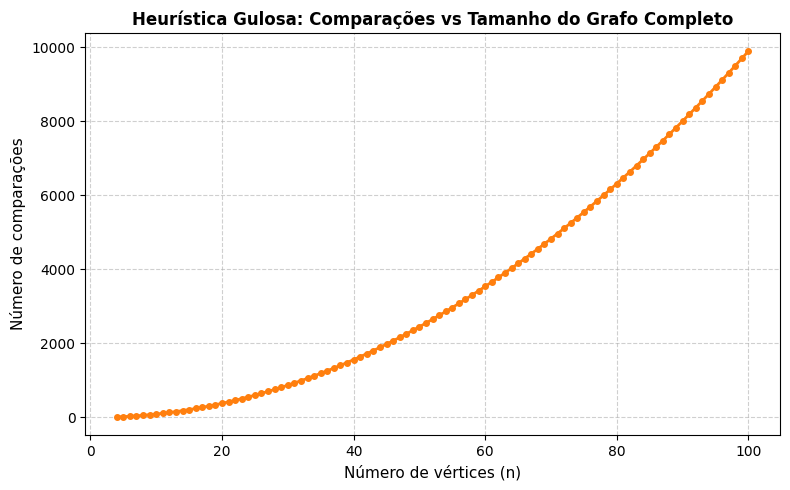

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(ns_gulosa, comparacoes_gulosa, marker='o', color='tab:orange', linewidth=2, markersize=4)
plt.xlabel('Número de vértices (n)', fontsize=11)
plt.ylabel('Número de comparações', fontsize=11)
plt.title('Heurística Gulosa: Comparações vs Tamanho do Grafo Completo', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Salvar imagem
os.makedirs('resultados/gulosa', exist_ok=True)
plt.savefig('resultados/gulosa/comparacoes.png', dpi=150, bbox_inches='tight')
print('[OK] Gráfico salvo em: resultados/gulosa/comparacoes.png')
plt.show()

### (f) Aplicar em instâncias grandes (10k e 1M vértices)

In [ ]:
def executar_instancia_grande_gulosa(caminho: str, nome: str, salvar_id: str):
    """Executa heurística gulosa em instância grande, mostra e salva comparações."""
    if not os.path.exists(caminho):
        print(f'⚠️  Arquivo não encontrado: {nome}')
        return None
    
    print(f'\n{"="*60}')
    print(f'Processando (Gulosa): {nome}')
    print(f'{"="*60}')
    
    print('Carregando grafo...')
    adj = carregar_grafo_ewd(caminho)
    print(f'✓ Grafo carregado: {len(adj):,} vértices')
    
    print(f'Executando Heurística Gulosa (origem = {ORIGEM})...')
    dist, parent, comp = heuristica_gulosa(adj, origem=ORIGEM)
    
    vertices_alcancados = sum(1 for d in dist.values() if d != inf)
    
    print(f'\n📊 RESULTADOS (GULOSA):')
    print(f'   Vértices: {len(dist):,}')
    print(f'   Comparações: {comp:,}')
    print(f'   Vértices alcançados: {vertices_alcancados:,}')
    
    # Salvar resultados
    os.makedirs('resultados/gulosa/instancias', exist_ok=True)
    arquivo_resultado = f'resultados/gulosa/instancias/{salvar_id}_gulosa.txt'
    with open(arquivo_resultado, 'w', encoding='utf-8') as f:
        f.write(f'HEURÍSTICA GULOSA - {nome}\n')
        f.write(f'{"="*60}\n')
        f.write(f'Origem: {ORIGEM}\n')
        f.write(f'Vértices: {len(dist):,}\n')
        f.write(f'Comparações: {comp:,}\n')
        f.write(f'Vértices alcançados: {vertices_alcancados:,}\n')
    
    print(f'💾 Resultado salvo em: {arquivo_resultado}')
    
    return comp


Processando (Gulosa): Instância 10.000 vértices
Carregando grafo...
✓ Grafo carregado: 10,000 vértices
Executando Heurística Gulosa (origem = 0)...

📊 RESULTADOS (GULOSA):
   Vértices: 10,000
   Comparações: 424
   Vértices alcançados: 28
✓ Grafo carregado: 10,000 vértices
Executando Heurística Gulosa (origem = 0)...

📊 RESULTADOS (GULOSA):
   Vértices: 10,000
   Comparações: 424
   Vértices alcançados: 28


In [ ]:
# Executar instância 10k
comp_gulosa_10k = executar_instancia_grande_gulosa(caminho_10k, 'Instância 10.000 vértices', '10k')

# Executar instância 1M (descomente se desejar)
comp_gulosa_1m = executar_instancia_grande_gulosa(caminho_1m, 'Instância 1.000.000 vértices', '1m')

---
# COMPARAÇÃO: DIJKSTRA vs HEURÍSTICA GULOSA
---

## Comparação em Grafos Completos (n=4 até N)

[OK] Gráfico comparativo salvo em: resultados/comparacao/dijkstra_vs_gulosa.png


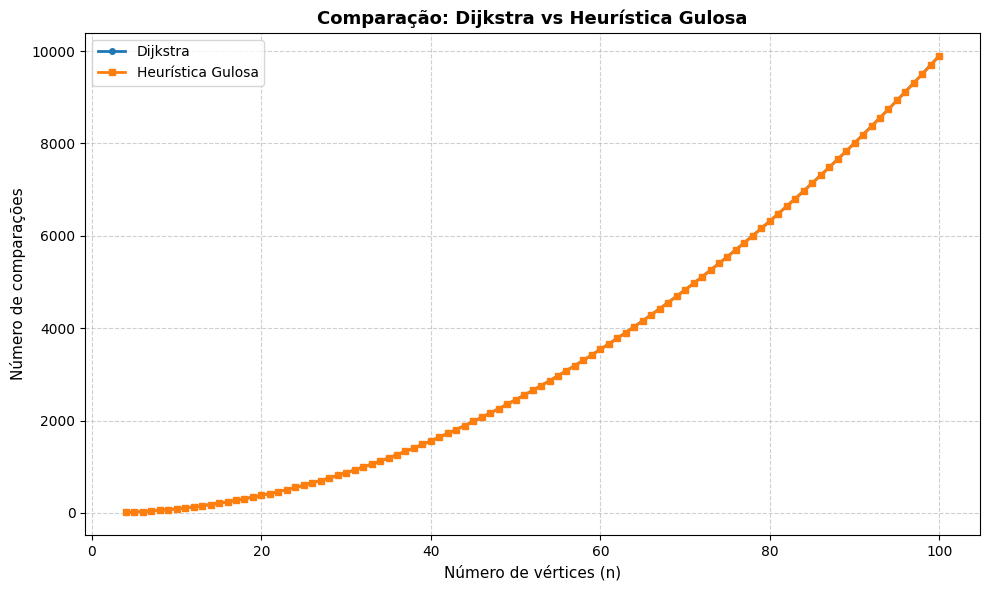


📊 COMPARAÇÃO FINAL
Tamanho do grafo: n=4 até n=100

Dijkstra:
  Mínimo comparações: 12
  Máximo comparações: 9,900

Heurística Gulosa:
  Mínimo comparações: 12
  Máximo comparações: 9,900

Redução média: 0.0%


In [ ]:
# Gráfico comparativo
plt.figure(figsize=(10, 6))
plt.plot(ns, comparacoes, marker='o', label='Dijkstra', linewidth=2, markersize=4)
plt.plot(ns_gulosa, comparacoes_gulosa, marker='s', label='Heurística Gulosa', linewidth=2, markersize=4)
plt.xlabel('Número de vértices (n)', fontsize=11)
plt.ylabel('Número de comparações', fontsize=11)
plt.title('Comparação: Dijkstra vs Heurística Gulosa', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

os.makedirs('resultados/comparacao', exist_ok=True)
plt.savefig('resultados/comparacao/dijkstra_vs_gulosa.png', dpi=150, bbox_inches='tight')
print('[OK] Gráfico comparativo salvo em: resultados/comparacao/dijkstra_vs_gulosa.png')
plt.show()

# Estatísticas comparativas
print('\n📊 COMPARAÇÃO - GRAFOS COMPLETOS')
print('='*60)
print(f'Tamanho do grafo: n={ns[0]} até n={ns[-1]}')
print(f'\nDijkstra:')
print(f'  Mínimo comparações: {min(comparacoes):,}')
print(f'  Máximo comparações: {max(comparacoes):,}')
print(f'\nHeurística Gulosa:')
print(f'  Mínimo comparações: {min(comparacoes_gulosa):,}')
print(f'  Máximo comparações: {max(comparacoes_gulosa):,}')
print(f'\nRedução média: {(1 - sum(comparacoes_gulosa)/sum(comparacoes))*100:.1f}%')

## Comparação em Instâncias Grandes (10k e 1M vértices)

In [ ]:
# Comparação das instâncias grandes
print('\n' + '='*70)
print('📊 COMPARAÇÃO FINAL - INSTÂNCIAS GRANDES')
print('='*70)

# Instância 10k
if comp_dijkstra_10k is not None and comp_gulosa_10k is not None:
    print('\n🔹 INSTÂNCIA 10.000 VÉRTICES')
    print('-' * 70)
    print(f'  Dijkstra:         {comp_dijkstra_10k:>15,} comparações')
    print(f'  Heurística Gulosa: {comp_gulosa_10k:>15,} comparações')
    reducao_10k = (1 - comp_gulosa_10k / comp_dijkstra_10k) * 100
    print(f'  Redução:          {reducao_10k:>15.2f}%')
    if comp_gulosa_10k < comp_dijkstra_10k:
        print(f'  ✓ Gulosa realizou {comp_dijkstra_10k - comp_gulosa_10k:,} comparações a menos')
    else:
        print(f'  ⚠ Gulosa realizou {comp_gulosa_10k - comp_dijkstra_10k:,} comparações a mais')

# Instância 1M (descomente após executar)
if 'comp_dijkstra_1m' in locals() and 'comp_gulosa_1m' in locals():
    if comp_dijkstra_1m is not None and comp_gulosa_1m is not None:
        print('\n🔹 INSTÂNCIA 1.000.000 VÉRTICES')
        print('-' * 70)
        print(f'  Dijkstra:         {comp_dijkstra_1m:>15,} comparações')
        print(f'  Heurística Gulosa: {comp_gulosa_1m:>15,} comparações')
        reducao_1m = (1 - comp_gulosa_1m / comp_dijkstra_1m) * 100
        print(f'  Redução:          {reducao_1m:>15.2f}%')
        if comp_gulosa_1m < comp_dijkstra_1m:
            print(f'  ✓ Gulosa realizou {comp_dijkstra_1m - comp_gulosa_1m:,} comparações a menos')
        else:
            print(f'  ⚠ Gulosa realizou {comp_gulosa_1m - comp_dijkstra_1m:,} comparações a mais')

print('\n' + '='*70)

# Gráfico comparativo das instâncias
comparacoes_instancias = []
if comp_dijkstra_10k is not None and comp_gulosa_10k is not None:
    comparacoes_instancias.append({
        'nome': '10k vértices',
        'dijkstra': comp_dijkstra_10k,
        'gulosa': comp_gulosa_10k
    })

# Descomente após executar 1M:
if 'comp_dijkstra_1m' in locals() and 'comp_gulosa_1m' in locals():
    if comp_dijkstra_1m is not None and comp_gulosa_1m is not None:
        comparacoes_instancias.append({
            'nome': '1M vértices',
            'dijkstra': comp_dijkstra_1m,
            'gulosa': comp_gulosa_1m
        })

# Plotar se houver dados
if comparacoes_instancias:
    import numpy as np
    
    nomes = [inst['nome'] for inst in comparacoes_instancias]
    dijkstra_vals = [inst['dijkstra'] for inst in comparacoes_instancias]
    gulosa_vals = [inst['gulosa'] for inst in comparacoes_instancias]
    
    x = np.arange(len(nomes))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, dijkstra_vals, width, label='Dijkstra', color='steelblue')
    bars2 = ax.bar(x + width/2, gulosa_vals, width, label='Heurística Gulosa', color='orange')
    
    ax.set_xlabel('Instância', fontsize=12)
    ax.set_ylabel('Número de Comparações', fontsize=12)
    ax.set_title('Comparação: Dijkstra vs Gulosa - Instâncias Grandes', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(nomes, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    
    # Adicionar valores nas barras
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height):,}',
                   ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('resultados/comparacao/instancias_grandes.png', dpi=150, bbox_inches='tight')
    print('\n💾 Gráfico de instâncias grandes salvo em: resultados/comparacao/instancias_grandes.png')
    plt.show()

# Salvar comparação em arquivo
os.makedirs('resultados/comparacao', exist_ok=True)
with open('resultados/comparacao/comparacao_completa.txt', 'w', encoding='utf-8') as f:
    f.write('COMPARAÇÃO COMPLETA: DIJKSTRA vs HEURÍSTICA GULOSA\n')
    f.write('='*70 + '\n\n')
    
    f.write(f'GRAFOS COMPLETOS (n={ns[0]} até n={ns[-1]})\n')
    f.write('-'*70 + '\n')
    f.write(f'Dijkstra - Mínimo: {min(comparacoes):,}, Máximo: {max(comparacoes):,}\n')
    f.write(f'Gulosa - Mínimo: {min(comparacoes_gulosa):,}, Máximo: {max(comparacoes_gulosa):,}\n')
    f.write(f'Redução média: {(1 - sum(comparacoes_gulosa)/sum(comparacoes))*100:.2f}%\n\n')
    
    if comp_dijkstra_10k is not None and comp_gulosa_10k is not None:
        f.write('INSTÂNCIA 10.000 VÉRTICES\n')
        f.write('-'*70 + '\n')
        f.write(f'Dijkstra: {comp_dijkstra_10k:,} comparações\n')
        f.write(f'Heurística Gulosa: {comp_gulosa_10k:,} comparações\n')
        f.write(f'Redução: {(1 - comp_gulosa_10k / comp_dijkstra_10k) * 100:.2f}%\n\n')
    
    # Descomente após executar 1M:
    if 'comp_dijkstra_1m' in locals() and 'comp_gulosa_1m' in locals():
        if comp_dijkstra_1m is not None and comp_gulosa_1m is not None:
            f.write('INSTÂNCIA 1.000.000 VÉRTICES\n')
            f.write('-'*70 + '\n')
            f.write(f'Dijkstra: {comp_dijkstra_1m:,} comparações\n')
            f.write(f'Heurística Gulosa: {comp_gulosa_1m:,} comparações\n')
            f.write(f'Redução: {(1 - comp_gulosa_1m / comp_dijkstra_1m) * 100:.2f}%\n')

print('💾 Comparação completa salva em: resultados/comparacao/comparacao_completa.txt')